## Import Data


In [124]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics # For confusion matrix
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

## Data reduction due to large number of dataset


In [125]:
pd.options.display.float_format = '{:.2f}'.format
df = pd.read_parquet('yellow_tripdata_2024-01.parquet')
print(len(df))
reduced_df = df.sample(n=25000,random_state=42)
reduced_df.to_csv('./reduced_dataset.csv', index=False)
# df.head()
print(len(reduced_df))
reduced_df.info()

2964624
25000
<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1725696 to 2134053
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               25000 non-null  int32         
 1   tpep_pickup_datetime   25000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  25000 non-null  datetime64[us]
 3   passenger_count        23818 non-null  float64       
 4   trip_distance          25000 non-null  float64       
 5   RatecodeID             23818 non-null  float64       
 6   store_and_fwd_flag     23818 non-null  object        
 7   PULocationID           25000 non-null  int32         
 8   DOLocationID           25000 non-null  int32         
 9   payment_type           25000 non-null  int64         
 10  fare_amount            25000 non-null  float64       
 11  extra                  25000 non-null  float64       
 12  mta_tax                25000 non-null  floa

## Describe data

In [126]:
reduced_df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,25000.00,25000,25000,23818.00,25000.00,23818.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,23818.00,23818.00
mean,1.75,2024-01-17 01:33:50.376959,2024-01-17 01:48:59.371440,1.33,3.21,2.12,165.82,165.49,1.16,18.13,1.46,0.48,3.32,0.53,0.98,26.76,2.26,0.14
min,1.00,2023-12-31 23:58:35,2024-01-01 00:13:06,0.00,0.00,1.00,1.00,1.00,0.00,-110.10,-7.50,-0.50,-0.01,-8.38,-1.00,-116.85,-2.50,-1.75
25%,1.00,2024-01-09 16:00:28.250000,2024-01-09 16:22:25.750000,1.00,1.00,1.00,132.00,116.00,1.00,8.60,0.00,0.50,0.98,0.00,1.00,15.30,2.50,0.00
50%,2.00,2024-01-17 11:43:07.500000,2024-01-17 12:02:31,1.00,1.68,1.00,162.00,162.00,1.00,12.80,1.00,0.50,2.66,0.00,1.00,20.00,2.50,0.00
75%,2.00,2024-01-24 19:38:42.750000,2024-01-24 19:54:15.500000,1.00,3.10,1.00,234.00,234.00,1.00,19.82,2.50,0.50,4.10,0.00,1.00,28.50,2.50,0.00
max,2.00,2024-01-31 23:56:06,2024-02-01 07:56:40,8.00,50.40,99.00,265.00,265.00,4.00,258.00,11.75,0.50,422.70,85.00,1.00,453.55,2.50,1.75
std,0.43,NaN,NaN,0.84,4.31,10.09,63.25,69.03,0.58,17.73,1.82,0.12,4.68,2.16,0.22,22.59,0.82,0.49


## Data Preprocessing / Transformation
### Feature Engineering - pickup datetime

1) The dataset has columns "pep_pickup_datetime" "tpep_dropoff_datetime" for that creatig new column Time slot with (Morning,Evening,night,afternoon) for better analysis using ColumnTransformer

In [80]:
class TimeSlotTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        time_slots = X.apply(lambda x: self.get_time_slot(x['tpep_pickup_datetime']), axis=1)
        return np.array(time_slots).reshape(-1, 1)
    
    def get_time_slot(self, time):
        if 5 <= time.hour < 12:
            return 'Morning'
        elif 12 <= time.hour < 17:
            return 'Afternoon'
        elif 17 <= time.hour < 21:
            return 'Evening'
        else:
            return 'Night'

pipeline = Pipeline(steps=[
    ('time_slot_transformer', ColumnTransformer(
        transformers=[
            ('time_slot', TimeSlotTransformer(), ['tpep_pickup_datetime'])
        ],
        remainder='drop'  # This drops other columns not specified in transformers
    ))
])
time_slots = pipeline.fit_transform(reduced_df).flatten()
time_slots

array(['Afternoon', 'Night', 'Night', ..., 'Evening', 'Night', 'Night'],
      dtype=object)

2) Creating a separate column which has the data for trip distance (short, long, medium)
but the the column has outliers in it and random values like 300,000 miles 
so creating a caping thershold 278 miles because one rows has 277 miles with correct data 

## Feature Engineering - trip distance
- (short, medium, long )

In [81]:
# cap_threshold = df['trip_distance'].quantile(0.99)
# # cap_threshold = 278
# df['trip_distance'] = df['trip_distance'].clip(upper=cap_threshold)
reduced_df['trip_distance'].describe()
short_threshold = reduced_df['trip_distance'].quantile(0.33)
long_threshold = reduced_df['trip_distance'].quantile(0.66)

# Create a new column for categorization
def categorize_distance(distance):
    if distance <= short_threshold:
        return 'short'
    elif distance <= long_threshold:
        return 'medium'
    else:
        return 'long'

distance_slots = reduced_df['trip_distance'].apply(categorize_distance)
# type(distance_slots)
time_slots

array(['Afternoon', 'Night', 'Night', ..., 'Evening', 'Night', 'Night'],
      dtype=object)

## Create duration column

In [127]:
reduced_df['duration'] = (reduced_df['tpep_dropoff_datetime'] - reduced_df['tpep_pickup_datetime'])/np.timedelta64(1,'m')
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1725696 to 2134053
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               25000 non-null  int32         
 1   tpep_pickup_datetime   25000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  25000 non-null  datetime64[us]
 3   passenger_count        23818 non-null  float64       
 4   trip_distance          25000 non-null  float64       
 5   RatecodeID             23818 non-null  float64       
 6   store_and_fwd_flag     23818 non-null  object        
 7   PULocationID           25000 non-null  int32         
 8   DOLocationID           25000 non-null  int32         
 9   payment_type           25000 non-null  int64         
 10  fare_amount            25000 non-null  float64       
 11  extra                  25000 non-null  float64       
 12  mta_tax                25000 non-null  float64       
 13

## Three important column to predict outliers are
- trip_distance
- fare_amount
- duration

### Visualizing

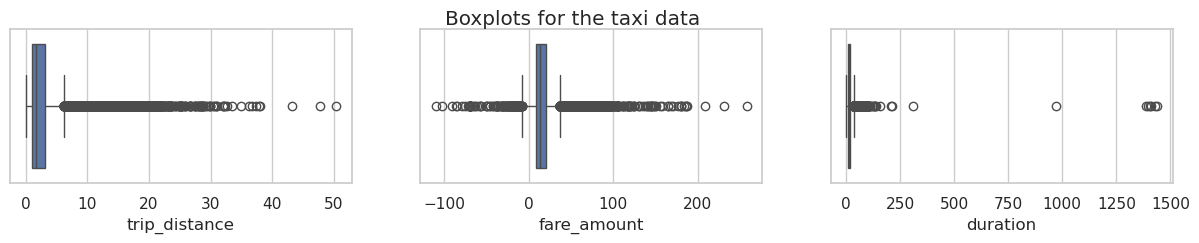

In [128]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2))
fig.suptitle('Boxplots for the taxi data')
sns.boxplot(ax=axes[0], x=reduced_df['trip_distance'])
sns.boxplot(ax=axes[1], x=reduced_df['fare_amount'])
sns.boxplot(ax=axes[2], x=reduced_df['duration'])
plt.show();

## The trip distance column outliers
- the trip distance column have 532 zero values out of 25000 which will not have a huge impact on datset so the trip distance column remains same

In [129]:
sum(reduced_df['trip_distance']==0)

532

## Fare amount outlier

In [130]:
reduced_df['fare_amount'].describe()

count   25000.00
mean       18.13
std        17.73
min      -110.10
25%         8.60
50%        12.80
75%        19.82
max       258.00
Name: fare_amount, dtype: float64

In [86]:
def oulierDetect(name_list,factor):
    for x in name_list:
        # if values less than zeros are considered as zeros
        reduced_df.loc[reduced_df[x] < 0, x] = 0
        # seting q3 value
        q3 = reduced_df[x].quantile(0.75)
        # setting the upper cap
        upper_cap = q3 + (factor * (q3 - reduced_df[x].quantile(0.25)))
        
        reduced_df.loc[reduced_df[x] > upper_cap, x] = upper_cap


In [131]:
oulierDetect(['fare_amount'], 6)
reduced_df['fare_amount'].describe()

count   25000.00
mean       18.24
std        16.22
min         0.00
25%         8.60
50%        12.80
75%        19.82
max        87.14
Name: fare_amount, dtype: float64

## Duration Outlier detection
- changeing the factor to 4 for better predictions

In [132]:
oulierDetect(['duration'], 4)
reduced_df['duration'].describe()


count   25000.00
mean       14.68
std        11.24
min         0.00
25%         7.12
50%        11.55
75%        18.70
max        65.03
Name: duration, dtype: float64

In [133]:
reduced_df['pickDrop'] = reduced_df['PULocationID'].astype(str) + ' ' + reduced_df['DOLocationID'].astype(str)
reduced_df['pickDrop'].head(2)

1725696    132 233
1581136     163 75
Name: pickDrop, dtype: object

## Mean Distance Column

In [134]:
pickDrop_Dis = reduced_df.groupby('pickDrop').mean(numeric_only=True)[['trip_distance']]
pickDrop_Dis[:10]

pickDrop_Dis_dict = pickDrop_Dis.to_dict()


pickDrop_Dis_dict = pickDrop_Dis_dict['trip_distance']

# len(pickDrop_Dis_dict)

reduced_df['mean_dis'] = reduced_df['pickDrop']


reduced_df['mean_dis'] = reduced_df['mean_dis'].map(pickDrop_Dis_dict)


reduced_df[(reduced_df['PULocationID']==100) & (reduced_df['DOLocationID']==231)][['mean_dis']]

,mean_dis
2779147,3.09
2947575,3.09
71435,3.09
1542045,3.09
2849538,3.09
2211672,3.09
2446692,3.09


## Mean Duriation Column

In [135]:
grouped = reduced_df.groupby('pickDrop').mean(numeric_only=True)[['duration']]
grouped

grouped_dict = grouped.to_dict()
grouped_dict = grouped_dict['duration']

reduced_df['mean_duration'] = reduced_df['pickDrop']
reduced_df['mean_duration'] = reduced_df['mean_duration'].map(grouped_dict)

reduced_df[(reduced_df['PULocationID']==100) & (reduced_df['DOLocationID']==231)][['mean_duration']]

,mean_duration
2779147,21.85
2947575,21.85
71435,21.85
1542045,21.85
2849538,21.85
2211672,21.85
2446692,21.85


In [136]:

reduced_df['dd'] = reduced_df['tpep_pickup_datetime'].dt.day_name().str.lower()

reduced_df['mm'] = reduced_df['tpep_pickup_datetime'].dt.strftime('%b').str.lower()

reduced_df['dd']

1725696     saturday
1581136     thursday
19137         monday
1682810       friday
511035      saturday
             ...    
2863684    wednesday
1902561       monday
2797172    wednesday
2048501    wednesday
2134053    wednesday
Name: dd, Length: 25000, dtype: object

In [137]:

reduced_df['peek_t'] = reduced_df['tpep_pickup_datetime'].dt.hour

# If day is Saturday or Sunday, impute 0 in `rush_hour` column
reduced_df.loc[reduced_df['dd'].isin(['saturday', 'sunday']), 'peek_t'] = 0
def peek_analzer(hour):
    if 6 <= hour['peek_t'] < 10:
        val = 1
    elif 16 <= hour['peek_t'] < 20:
        val = 1
    else:
        val = 0
    return val
reduced_df['peek_t'] = reduced_df.apply(peek_analzer, axis=1)
reduced_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,duration,pickDrop,mean_dis,mean_duration,dd,mm,peek_t
1725696,2,2024-01-20 13:31:30,2024-01-20 14:03:25,2.00,17.14,2.00,N,132,233,1,...,90.96,2.50,1.75,31.92,132 233,17.06,30.96,saturday,jan,0
1581136,2,2024-01-18 21:52:46,2024-01-18 22:03:21,1.00,2.49,1.00,N,163,75,1,...,22.50,2.50,0.00,10.58,163 75,2.50,15.03,thursday,jan,0
19137,2,2024-01-01 03:43:58,2024-01-01 03:50:47,2.00,1.84,1.00,N,127,20,2,...,12.50,0.00,0.00,6.82,127 20,1.84,6.82,monday,jan,0
1682810,1,2024-01-19 22:20:12,2024-01-19 22:50:12,1.00,3.60,1.00,N,186,263,1,...,33.95,2.50,0.00,30.00,186 263,3.96,24.08,friday,jan,0
511035,2,2024-01-06 22:41:50,2024-01-06 22:43:24,1.00,0.04,1.00,N,238,238,2,...,6.20,0.00,0.00,1.57,238 238,0.56,4.05,saturday,jan,0


## The mean duration correlates with target value

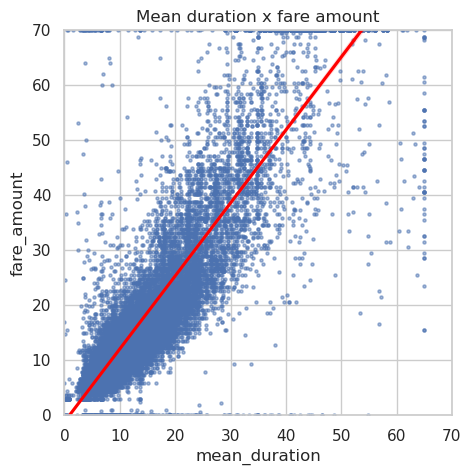

In [116]:
sns.set(style='whitegrid')
f = plt.figure()
f.set_figwidth(5)
f.set_figheight(5)
sns.regplot(x=reduced_df['mean_duration'], y=reduced_df['fare_amount'],
            scatter_kws={'alpha':0.5, 's':5},
            line_kws={'color':'red'})
plt.ylim(0, 70)
plt.xlim(0, 70)
plt.title('Mean duration x fare amount')
plt.show()

In [95]:
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1725696 to 2134053
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               25000 non-null  int32         
 1   tpep_pickup_datetime   25000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  25000 non-null  datetime64[us]
 3   passenger_count        23818 non-null  float64       
 4   trip_distance          25000 non-null  float64       
 5   RatecodeID             23818 non-null  float64       
 6   store_and_fwd_flag     23818 non-null  object        
 7   PULocationID           25000 non-null  int32         
 8   DOLocationID           25000 non-null  int32         
 9   payment_type           25000 non-null  int64         
 10  fare_amount            25000 non-null  float64       
 11  extra                  25000 non-null  float64       
 12  mta_tax                25000 non-null  float64       
 13

In [138]:
def handle_outliers(df, column_name):
    """
    Handle outliers in a DataFrame column by replacing values outside the 1.5 * IQR range with the median.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    column_name (str): The name of the column to handle outliers for.
    
    Returns:
    pd.DataFrame: The DataFrame with outliers handled.
    """
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Defining outliers as those outside 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    median_value = df[column_name].median()
    
    # Replace outliers with the median value
    df[column_name] = df[column_name].apply(lambda x: median_value if x < lower_bound or x > upper_bound else x)
    
    return df

In [139]:
rdDf = reduced_df.copy()

rdDf = rdDf.drop(['tpep_dropoff_datetime', 'tpep_pickup_datetime',
               'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
               'payment_type', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
               'total_amount', 'tpep_dropoff_datetime', 'tpep_pickup_datetime', 'duration','Airport_fee',"congestion_surcharge","pickDrop","dd","mm"
               ], axis=1)
# filling missing values for passsenger count
rdDf['passenger_count'].fillna(1, inplace=True)
rdDf = handle_outliers(rdDf, 'fare_amount')
rdDf = handle_outliers(rdDf, 'mean_dis')
rdDf = handle_outliers(rdDf, 'mean_duration')
rdDf.info()


<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 1725696 to 2134053
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         25000 non-null  int32  
 1   passenger_count  25000 non-null  float64
 2   fare_amount      25000 non-null  float64
 3   mean_dis         25000 non-null  float64
 4   mean_duration    25000 non-null  float64
 5   peek_t           25000 non-null  int64  
dtypes: float64(4), int32(1), int64(1)
memory usage: 1.2 MB


/tmp/ipykernel_19622/874318530.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rdDf['passenger_count'].fillna(1, inplace=True)


In [140]:
rdDf.corr(method='pearson')

,VendorID,passenger_count,fare_amount,mean_dis,mean_duration,peek_t
VendorID,1.00,0.10,-0.00,0.01,0.00,-0.01
passenger_count,0.10,1.00,-0.00,-0.01,0.00,-0.04
fare_amount,-0.00,-0.00,1.00,0.64,0.68,-0.02
mean_dis,0.01,-0.01,0.64,1.00,0.68,-0.03
mean_duration,0.00,0.00,0.68,0.68,1.00,-0.03
peek_t,-0.01,-0.04,-0.02,-0.03,-0.03,1.00


## Strongest Correlations:

- fare_amount with mean_dis (0.89)
- fare_amount with mean_duration (0.82)
- mean_dis with mean_duration (0.86)


diffrentiating X and y which is features and target

In [141]:

X = rdDf.drop(columns=['fare_amount'])

y = rdDf[['fare_amount']]

# Display first few rows
X.head()

,VendorID,passenger_count,mean_dis,mean_duration,peek_t
1725696,2,2.00,1.65,30.96,0
1581136,2,1.00,2.50,15.03,0
19137,2,2.00,1.84,6.82,0
1682810,1,1.00,3.96,24.08,0
511035,2,1.00,0.56,4.05,0


In [142]:
X['VendorID'] = X['VendorID'].astype(str)

X = pd.get_dummies(X, drop_first=True)
X.isna().sum()

passenger_count    0
mean_dis           0
mean_duration      0
peek_t             0
VendorID_2         0
dtype: int64

## Training the data Linear regression
- Feature data set is -> VendorID	passenger_count	mean_dis	mean_duration	peek_t
- Target value is fare_amount

In [143]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [144]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
print('X_train scaled:', X_train_scaled)


X_train scaled: [[-0.38327079 -0.22808348 -0.29621442 -0.66761775  0.57873591]
 [-0.38327079 -0.04710209  0.10527265 -0.66761775  0.57873591]
 [-0.38327079 -0.11109471 -0.14520725  1.49786311 -1.72790383]
 ...
 [-0.38327079 -0.84218515 -0.83137834 -0.66761775 -1.72790383]
 [-0.38327079  2.96517365  0.67828061 -0.66761775  0.57873591]
 [ 0.84143217 -0.74172178 -0.62529998  1.49786311  0.57873591]]


In [145]:
lr=LinearRegression()
lr.fit(X_train_scaled, y_train)


LinearRegression()

In [146]:
r_sq = lr.score(X_train_scaled, y_train)
print('Coefficient of determination:', r_sq)
y_pred_train = lr.predict(X_train_scaled)
print('R^2:', r2_score(y_train, y_pred_train))
print('MAE:', mean_absolute_error(y_train, y_pred_train))
print('MSE:', mean_squared_error(y_train, y_pred_train))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred_train)))

Coefficient of determination: 0.5235903619913476
R^2: 0.5235903619913476
MAE: 2.9961865089118844
MSE: 22.039093894749552
RMSE: 4.694581333276648


In [147]:
X_test_scaled = scaler.transform(X_test)

In [148]:
r_sq_test = lr.score(X_test_scaled, y_test)
print('Coefficient of determination:', r_sq_test)
y_pred_test = lr.predict(X_test_scaled)
print('R^2:', r2_score(y_test, y_pred_test))
print('MAE:', mean_absolute_error(y_test,y_pred_test))
print('MSE:', mean_squared_error(y_test, y_pred_test))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_test)))

Coefficient of determination: 0.519872981674181
R^2: 0.519872981674181
MAE: 3.017278535215991
MSE: 22.121454544564966
RMSE: 4.703345037796501


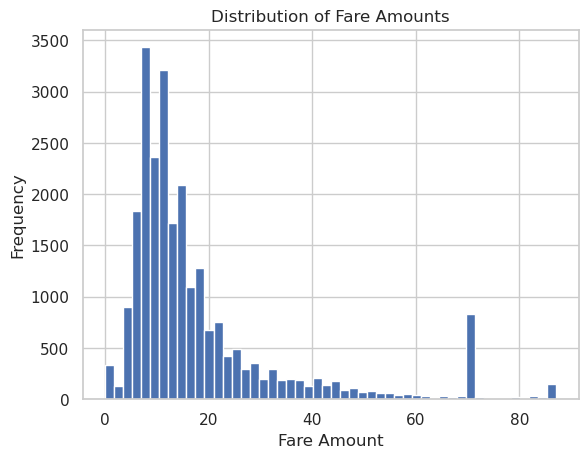

In [97]:
# single_value = [[1, 2, 17.06, 30.96, 0]]
# sv_scaled = scaler.transform(single_value)
# predicted_fare = lr.predict(sv_scaled)

# # VendorID	passenger_count	fare_amount	mean_dis	mean_duration	peek_t
# # 19137	2	2.00	10.00	1.84	6.82	0
# print(f"Predicted fare amount: {predicted_fare[0]}")
# # rdDf[rdDf['fare_amount']>52.00][:1]
plt.hist(rdDf['fare_amount'], bins=50)
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Fare Amounts')
plt.show()

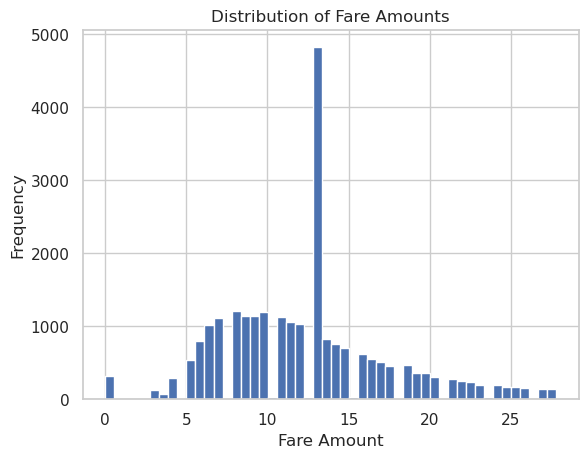

count   25000.00
mean       12.37
std         5.17
min         0.00
25%         8.60
50%        12.80
75%        14.90
max        27.80
Name: fare_amount, dtype: float64

In [119]:
Q1 = rdDf['fare_amount'].quantile(0.25)
Q3 = rdDf['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

# Defining outliers as those outside 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = rdDf[(rdDf['fare_amount'] < lower_bound) | (rdDf['fare_amount'] > upper_bound)]
non_outliers = rdDf[(rdDf['fare_amount'] >= lower_bound) & (rdDf['fare_amount'] <= upper_bound)]
# non_outliers
# rdDf['fare_amount'] = rdDf['fare_amount'].apply(lambda x: upper_bound if x > upper_bound else x)
# df['fare_amount_log'] = df['fare_amount'].apply(lambda x: np.log(x + 1))  # Adding 1 to handle log(0)
median_fare = rdDf['fare_amount'].median()
rdDf['fare_amount'] = rdDf['fare_amount'].apply(lambda x: median_fare if x > upper_bound else x)


rdDf['fare_amount'].describe()
plt.hist(rdDf['fare_amount'], bins=50)
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Fare Amounts')
plt.show()
rdDf['fare_amount'].describe()

In [149]:
results = pd.DataFrame(data={'actual': y_test['fare_amount'],
                             'predicted': y_pred_test.ravel()})
results['residual'] = results['actual'] - results['predicted']
results.head()

,actual,predicted,residual
20929,10.00,11.77,-1.77
117321,12.80,11.46,1.34
741403,11.40,15.86,-4.46
109663,12.80,12.74,0.06
1531687,7.90,8.77,-0.87


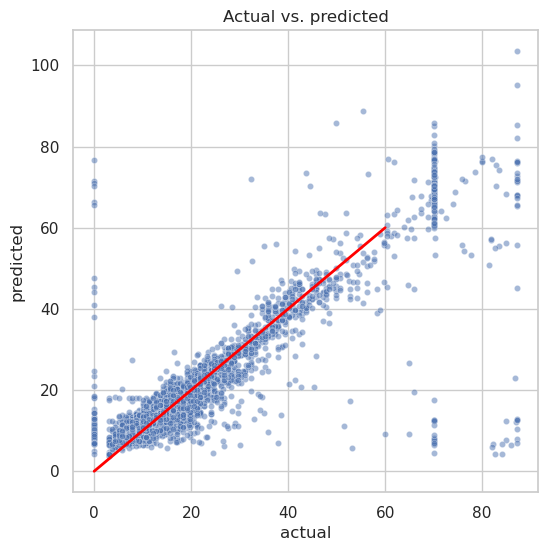

In [45]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.set(style='whitegrid')
sns.scatterplot(x='actual',
                y='predicted',
                data=results,
                s=20,
                alpha=0.5,
                ax=ax
)
plt.plot([0,60], [0,60], c='red', linewidth=2)
plt.title('Actual vs. predicted');

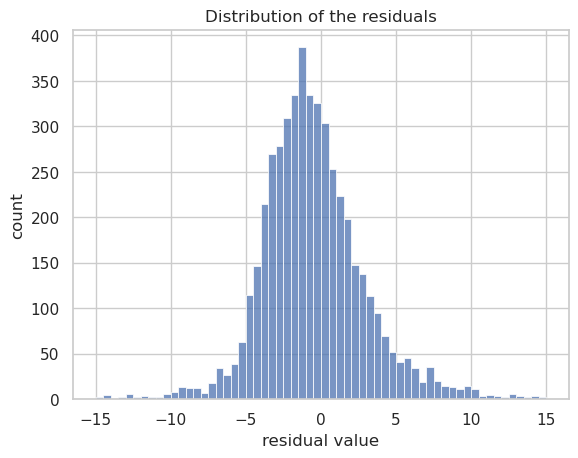

In [46]:
sns.histplot(results['residual'], bins=np.arange(-15,15.5,0.5))
plt.title('Distribution of the residuals')
plt.xlabel('residual value')
plt.ylabel('count');

In [47]:
results['residual'].mean()

-0.03658906521322647

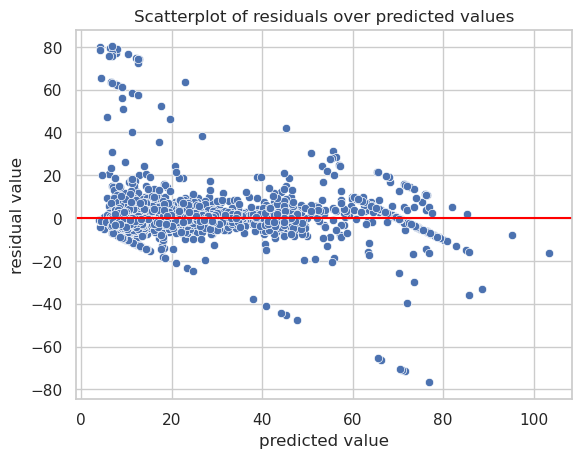

In [48]:
sns.scatterplot(x='predicted', y='residual', data=results)
plt.axhline(0, c='red')
plt.title('Scatterplot of residuals over predicted values')
plt.xlabel('predicted value')
plt.ylabel('residual value')
plt.show()

In [49]:
coefficients = pd.DataFrame(lr.coef_, columns=X.columns)
coefficients

,passenger_count,mean_dis,mean_duration,peek_t,VendorID_2
0,0.29,10.97,3.87,0.04,0.16


In [50]:
print(X_train['mean_dis'].std())


print(11.24 / X_train['mean_dis'].std())

4.173212314721292
2.693368837322302


## Lasso regression

In [51]:
lasso = Lasso(alpha=1.0)

In [52]:
lasso.fit(X_train_scaled, y_train)

Lasso()

In [53]:
r_sq = lasso.score(X_train_scaled, y_train)
print('Coefficient of determination:', r_sq)
y_pred_train = lasso.predict(X_train_scaled)
print('R^2:', r2_score(y_train, y_pred_train))
print('MAE:', mean_absolute_error(y_train, y_pred_train))
print('MSE:', mean_squared_error(y_train, y_pred_train))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred_train)))

Coefficient of determination: 0.7967347073987304
R^2: 0.7967347073987304
MAE: 3.6912097304778544
MSE: 52.91380606386476
RMSE: 7.27418765662976


In [54]:
r_sq_test = lasso.score(X_test_scaled, y_test)
print('Coefficient of determination:', r_sq_test)
y_pred_test = lasso.predict(X_test_scaled)
print('R^2:', r2_score(y_test, y_pred_test))
print('MAE:', mean_absolute_error(y_test,y_pred_test))
print('MSE:', mean_squared_error(y_test, y_pred_test))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_test)))

Coefficient of determination: 0.781326445799174
R^2: 0.781326445799174
MAE: 3.740542901945411
MSE: 59.98884547150666
RMSE: 7.745246637228969


In [74]:
results2 = pd.DataFrame(data={'actual': y_test['fare_amount'],
                             'predicted': y_pred_test.ravel()})
results2['residual'] = results2['actual'] - results2['predicted']
# print(results.head())
# results2.head()
y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 20929 to 420183
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   fare_amount  5000 non-null   float64
dtypes: float64(1)
memory usage: 78.1 KB
